In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# ── Load data ──────────────────────────────────────────────────────────────
minimal = pd.read_csv('MoleculeMinimal/Tailles.csv')
full    = pd.read_csv('MoleculeFull/Tailles.csv')

print('MoleculeMinimal shape:', minimal.shape)
print('MoleculeFull    shape:', full.shape)
minimal.head()

MoleculeMinimal shape: (45, 3)
MoleculeFull    shape: (45, 3)


,x,y,temps
0,2,2,30.206
1,2,4,15.500
2,2,8,8.211
3,2,16,4.498
4,2,32,2.837


In [38]:
# ── Merge and compute ratio ────────────────────────────────────────────────
merged = minimal.merge(full, on=['x', 'y'], suffixes=('_minimal', '_full'))

merged['ratio'] = merged['temps_full'] / merged['temps_minimal']
print('Merged shape:', merged.shape)
print(f"Ratio range : {merged['ratio'].min():.3f} – {merged['ratio'].max():.3f}")
merged.head(10)

Merged shape: (45, 5)
Ratio range : 9.408 – 18.061


,x,y,temps_minimal,temps_full,ratio
0,2,2,30.206,284.166,9.407601
1,2,4,15.500,151.802,9.793677
2,2,8,8.211,86.457,10.529412
3,2,16,4.498,55.372,12.310360
4,2,32,2.837,43.363,15.284808
5,2,64,2.713,44.047,16.235533
6,2,128,2.964,44.745,15.096154
7,2,256,3.312,46.574,14.062198
8,2,512,3.489,49.597,14.215248
9,4,2,8.794,94.460,10.741415


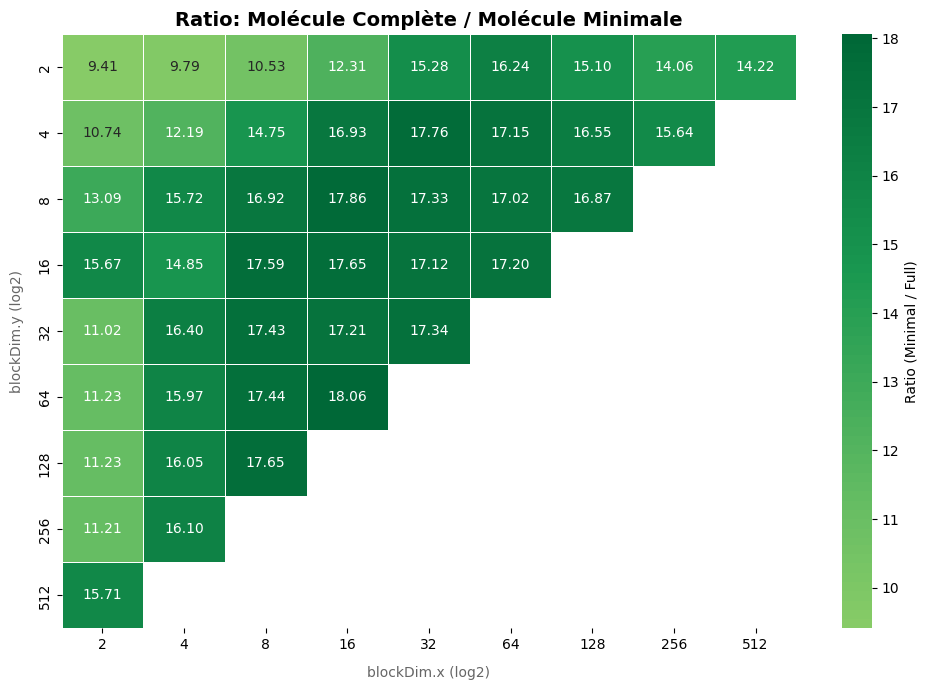

Saved → ratio_heatmap.png


In [39]:
# ── Heatmap of ratio ──────────────────────────────────────────────────────
pivot = merged.pivot(index='x', columns='y', values='ratio')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    pivot,
    ax=ax,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=1.0,
    linewidths=0.5,
    cbar_kws={'label': 'Ratio (Minimal / Full)'}
)
ax.set_title('Ratio: Molécule Complète / Molécule Minimale', fontsize=14, fontweight='bold')
ax.set_xlabel("blockDim.x (log2)", fontsize=10, color="#666", labelpad=10)
ax.set_ylabel("blockDim.y (log2)", fontsize=10, color="#666", labelpad=10)
plt.tight_layout()
plt.savefig('ratio_heatmap.png', dpi=150)
plt.show()
print('Saved → ratio_heatmap.png')

In [40]:
# ── Load data ──────────────────────────────────────────────────────────────
minimal = pd.read_csv('MoleculeMinimal/Times.csv')
full    = pd.read_csv('MoleculeFull/Times.csv')

print('MoleculeMinimal shape:', minimal.shape)
print('MoleculeFull    shape:', full.shape)
minimal.head()

MoleculeMinimal shape: (13, 2)
MoleculeFull    shape: (11, 2)


,Size,Time (s)
0,1000,0.103
1,2000,0.246
2,3000,0.402
3,5000,0.711
4,8000,1.378


In [41]:
# ── Merge and compute ratio ────────────────────────────────────────────────
merged = minimal.merge(full, on=['Size'], suffixes=('_minimal', '_full'))

merged['ratio'] = merged['Time (s)_full'] / merged['Time (s)_minimal']
print('Merged shape:', merged.shape)
print(f"Ratio range : {merged['ratio'].min():.3f} – {merged['ratio'].max():.3f}")
merged.head(10)


Merged shape: (11, 4)
Ratio range : 9.325 – 24.948


,Size,Time (s)_minimal,Time (s)_full,ratio
0,1000,0.103,0.977,9.485437
1,2000,0.246,2.294,9.325203
2,3000,0.402,4.065,10.111940
3,5000,0.711,9.409,13.233474
4,8000,1.378,21.492,15.596517
5,10000,1.883,32.887,17.465215
6,15000,3.474,68.244,19.644214
7,20000,5.563,120.742,21.704476
8,30000,11.263,268.789,23.864778
9,40000,19.088,470.030,24.624371


Text(0.5, 1.0, "Ratio du temps d'exécution en fonction du nombre de photos")

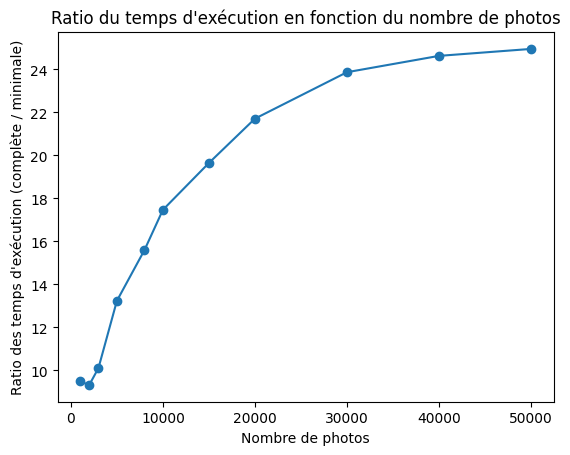

In [42]:
plt.plot(merged["Size"], merged["ratio"], marker='o')
plt.xlabel("Nombre de photos")
plt.ylabel("Ratio des temps d'exécution (complète / minimale)")
plt.title("Ratio du temps d'exécution en fonction du nombre de photos")

Text(0.5, 1.0, "Ratio du temps d'exécution en fonction du nombre de photos")

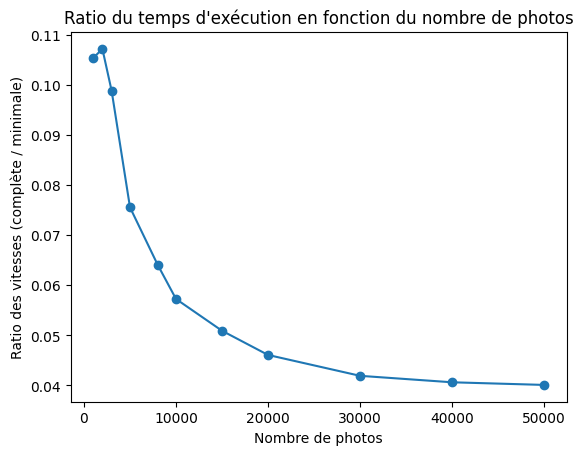

In [44]:
merged["nb rmsd"] = merged["Size"] * (merged["Size"] - 1) / 2
merged["speed minimal"] = merged["nb rmsd"] / merged["Time (s)_minimal"]
merged["speed full"] = merged["nb rmsd"] / merged["Time (s)_full"]
merged["ratio speed"] = merged["speed full"] / merged["speed minimal"]

plt.plot(merged["Size"], merged["ratio speed"], marker='o')
plt.xlabel("Nombre de photos")
plt.ylabel("Ratio des vitesses (complète / minimale)")
plt.title("Ratio du temps d'exécution en fonction du nombre de photos")